In [666]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [667]:
#create synthtetic dataset
from sklearn.datasets import make_classification

In [668]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)

In [669]:
X

array([[-0.20500167, -0.69297891],
       [ 0.23678447, -1.05418847],
       [ 0.95608552,  1.33227047],
       ...,
       [-0.72288665,  0.43715153],
       [ 1.46023975, -0.94844004],
       [ 0.26440938,  1.0761872 ]], shape=(1000, 2))

In [670]:
y
pd.DataFrame(X)[0]

0     -0.205002
1      0.236784
2      0.956086
3      2.361961
4     -0.510260
         ...   
995    0.258712
996   -2.181997
997   -0.722887
998    1.460240
999    0.264409
Name: 0, Length: 1000, dtype: float64

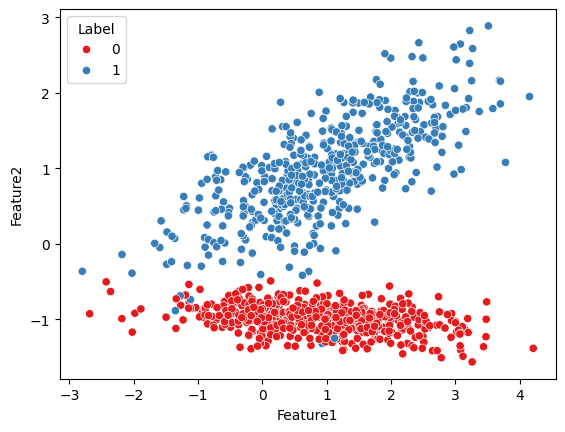

In [671]:
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df['Label'] = y

# 3️⃣ Plot with seaborn
sns.scatterplot(data=df, x='Feature1', y='Feature2', hue='Label', palette='Set1')
plt.show()

In [672]:
from sklearn.model_selection import train_test_split

In [673]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [674]:
from sklearn.svm import SVC

In [675]:
svc=SVC(kernel='linear')

In [676]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [677]:
y_pred=svc.predict(X_test)

In [678]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [679]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00       117

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [680]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00       117

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

1.0


In [681]:
rbf=SVC(kernel="rbf")

In [682]:
rbf.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [683]:
y_pred1=rbf.predict(X_test)

In [684]:
print(classification_report(y_test,y_pred1))
print(accuracy_score(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       133
           1       1.00      0.99      1.00       117

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

0.996


In [685]:
poly=SVC(kernel="poly")

In [686]:
poly.fit(X_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [687]:
y_pred2=rbf.predict(X_test)

In [688]:
print(classification_report(y_test,y_pred2))
print(accuracy_score(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       133
           1       1.00      0.99      1.00       117

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

0.996


In [689]:
from sklearn.model_selection import GridSearchCV

In [690]:
param_grid={'C': [0.1,.1,10,100,1000],
    'gamma':[1,0.1,0.01,0.001,0.0001],
    'kernel':['rbf']

}

In [691]:
grid=GridSearchCV(SVC(),param_grid=param_grid,cv=5,verbose=3,refit=True)

In [692]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.987 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.987 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.973 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.993 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.973 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.967 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.980 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 0.1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1000


In [693]:
grid.best_params_

{'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}

In [694]:
y_pred3=grid.predict(X_test)
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00       117

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

